# Output BAB 4.3 — Pembagian Dataset Spasial dan Validasi Eksperimental

Notebook ini khusus membuat artefak untuk subbab **4.3 Pembagian Dataset Spasial dan Validasi Eksperimental** sesuai `TODO_BAB_4_Lengkap.md` dan `TODO_BAB_4_Checklist_Output.md`. Output mencakup tabel 5-fold spatial CV, tabel jumlah tile train/validation/final test per fold, diagram spatial split, grafik jumlah tile, narasi interpretasi, dan checklist cakupan TODO.


## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper.


In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [2]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.3 Tabel 5-Fold Spatial Cross-Validation

Mendefinisikan fold validasi berbasis wilayah dan mengunci Aceh_Utara sebagai final test region.


In [3]:
fold_defs = [
    (0, ["Pidie", "Pidie_Jaya"]),
    (1, ["Aceh_Besar", "Banda_Aceh"]),
    (2, ["Aceh_Tamiang", "Aceh_Timur"]),
    (3, ["Bireuen", "Langsa"]),
    (4, ["Agam", "Pasaman_Barat"]),
]
CV_REGIONS = sorted({region for _, regions in fold_defs for region in regions})
TEST_REGION = "Aceh_Utara"

fold_rows = []
for fold, val_regions in fold_defs:
    train_regions = [r for r in CV_REGIONS if r not in val_regions]
    fold_rows.append({
        "fold": fold,
        "validation_regions": ", ".join(val_regions),
        "training_regions": ", ".join(train_regions),
        "held_out_final_test": TEST_REGION,
        "cv_region_count_train": len(train_regions),
        "cv_region_count_validation": len(val_regions),
        "purpose": "hyperparameter tuning and training stability",
        "leakage_control": "region-level split; final test region excluded from CV",
    })
five_fold_cv = pd.DataFrame(fold_rows)
save_table(five_fold_cv, "4_3_five_fold_spatial_cv.csv")


saved table: outputs/bab4/tables/4_3_five_fold_spatial_cv.csv (5 rows)


,fold,validation_regions,training_regions,held_out_final_test,cv_region_count_train,cv_region_count_validation,purpose,leakage_control
0,0,"Pidie, Pidie_Jaya","Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Agam, Ba...",Aceh_Utara,8,2,hyperparameter tuning and training stability,region-level split; final test region excluded...
1,1,"Aceh_Besar, Banda_Aceh","Aceh_Tamiang, Aceh_Timur, Agam, Bireuen, Langs...",Aceh_Utara,8,2,hyperparameter tuning and training stability,region-level split; final test region excluded...
2,2,"Aceh_Tamiang, Aceh_Timur","Aceh_Besar, Agam, Banda_Aceh, Bireuen, Langsa,...",Aceh_Utara,8,2,hyperparameter tuning and training stability,region-level split; final test region excluded...
3,3,"Bireuen, Langsa","Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Agam, Ba...",Aceh_Utara,8,2,hyperparameter tuning and training stability,region-level split; final test region excluded...
4,4,"Agam, Pasaman_Barat","Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Banda_Ac...",Aceh_Utara,8,2,hyperparameter tuning and training stability,region-level split; final test region excluded...


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_3_five_fold_spatial_cv.csv')

## 4.3 Jumlah Tile Train/Validation/Final Test per Fold

Menghitung jumlah tile dari folder `by_region` sehingga tabel mengikuti rancangan spatial CV, bukan random split tile.


In [4]:
def by_region_tile_counts() -> pd.DataFrame:
    table_path = TABLE_DIR / "4_2_tile_distribution_by_split_region.csv"
    if table_path.exists():
        df = pd.read_csv(table_path)
        if {"region", "total_tile"}.issubset(df.columns):
            return df[["region", "total_tile", "valid_tile", "tile_positive", "tile_background"]].copy()
    rows = []
    for region in REGIONS:
        files = sorted((DATASET / "tiles" / "7ch" / "by_region" / region).glob("*.npz"))
        rows.append({"region": region, "total_tile": len(files), "valid_tile": np.nan, "tile_positive": np.nan, "tile_background": np.nan})
    return pd.DataFrame(rows)

region_counts = by_region_tile_counts()
count_lookup = region_counts.set_index("region").to_dict("index") if not region_counts.empty else {}

def sum_regions(regions: list[str], column: str = "total_tile") -> int:
    values = []
    for region in regions:
        val = count_lookup.get(region, {}).get(column, 0)
        if pd.isna(val):
            val = 0
        values.append(int(val))
    return int(sum(values))

split_rows = []
fold_count_rows = []
for fold, val_regions in fold_defs:
    train_regions = [r for r in CV_REGIONS if r not in val_regions]
    test_regions = [TEST_REGION]
    for role, regions in [("train", train_regions), ("validation", val_regions), ("final_test", test_regions)]:
        split_rows.append({
            "fold": fold,
            "role": role,
            "regions": ", ".join(regions),
            "region_count": len(regions),
            "tile_count": sum_regions(regions, "total_tile"),
            "valid_tile_count": sum_regions(regions, "valid_tile"),
            "positive_tile_count": sum_regions(regions, "tile_positive"),
            "background_tile_count": sum_regions(regions, "tile_background"),
        })
    fold_count_rows.append({
        "fold": fold,
        "train_regions": ", ".join(train_regions),
        "validation_regions": ", ".join(val_regions),
        "final_test_region": TEST_REGION,
        "train_tile_count": sum_regions(train_regions),
        "validation_tile_count": sum_regions(val_regions),
        "final_test_tile_count": sum_regions(test_regions),
        "total_train_val_tile_count": sum_regions(train_regions + val_regions),
        "total_including_final_test_tile_count": sum_regions(train_regions + val_regions + test_regions),
        "train_positive_tile_count": sum_regions(train_regions, "tile_positive"),
        "validation_positive_tile_count": sum_regions(val_regions, "tile_positive"),
        "final_test_positive_tile_count": sum_regions(test_regions, "tile_positive"),
    })

spatial_split = pd.DataFrame(split_rows)
save_table(spatial_split, "4_3_spatial_split_summary.csv")

fold_tile_counts = pd.DataFrame(fold_count_rows)
save_table(fold_tile_counts, "4_3_fold_tile_counts.csv")

region_role_rows = []
for region in REGIONS:
    if region == TEST_REGION:
        role = "final_test"
        folds_as_validation = "-"
    elif region in CV_REGIONS:
        role = "cross_validation"
        folds_as_validation = ", ".join(str(fold) for fold, regs in fold_defs if region in regs)
    else:
        role = "unused_or_external"
        folds_as_validation = "-"
    region_role_rows.append({
        "region": region,
        "role": role,
        "folds_as_validation": folds_as_validation,
        "total_tile": sum_regions([region]),
        "positive_tile": sum_regions([region], "tile_positive"),
        "background_tile": sum_regions([region], "tile_background"),
    })
region_role_summary = pd.DataFrame(region_role_rows)
save_table(region_role_summary, "4_3_region_role_summary.csv")


saved table: outputs/bab4/tables/4_3_spatial_split_summary.csv (15 rows)


,fold,role,regions,region_count,tile_count,valid_tile_count,positive_tile_count,background_tile_count
0,0,train,"Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Agam, Ba...",8,3206,2811,1378,1433
1,0,validation,"Pidie, Pidie_Jaya",2,724,620,260,360
2,0,final_test,Aceh_Utara,1,493,462,292,170
3,1,train,"Aceh_Tamiang, Aceh_Timur, Agam, Bireuen, Langs...",8,3396,2939,1356,1583
4,1,validation,"Aceh_Besar, Banda_Aceh",2,534,492,282,210
5,1,final_test,Aceh_Utara,1,493,462,292,170
6,2,train,"Aceh_Besar, Agam, Banda_Aceh, Bireuen, Langsa,...",8,2402,2183,1071,1112
7,2,validation,"Aceh_Tamiang, Aceh_Timur",2,1528,1248,567,681
8,2,final_test,Aceh_Utara,1,493,462,292,170
9,3,train,"Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Agam, Ba...",8,3586,3093,1428,1665


saved table: outputs/bab4/tables/4_3_fold_tile_counts.csv (5 rows)


,fold,train_regions,validation_regions,final_test_region,train_tile_count,validation_tile_count,final_test_tile_count,total_train_val_tile_count,total_including_final_test_tile_count,train_positive_tile_count,validation_positive_tile_count,final_test_positive_tile_count
0,0,"Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Agam, Ba...","Pidie, Pidie_Jaya",Aceh_Utara,3206,724,493,3930,4423,1378,260,292
1,1,"Aceh_Tamiang, Aceh_Timur, Agam, Bireuen, Langs...","Aceh_Besar, Banda_Aceh",Aceh_Utara,3396,534,493,3930,4423,1356,282,292
2,2,"Aceh_Besar, Agam, Banda_Aceh, Bireuen, Langsa,...","Aceh_Tamiang, Aceh_Timur",Aceh_Utara,2402,1528,493,3930,4423,1071,567,292
3,3,"Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Agam, Ba...","Bireuen, Langsa",Aceh_Utara,3586,344,493,3930,4423,1428,210,292
4,4,"Aceh_Besar, Aceh_Tamiang, Aceh_Timur, Banda_Ac...","Agam, Pasaman_Barat",Aceh_Utara,3130,800,493,3930,4423,1319,319,292


saved table: outputs/bab4/tables/4_3_region_role_summary.csv (11 rows)


,region,role,folds_as_validation,total_tile,positive_tile,background_tile
0,Aceh_Besar,cross_validation,1,518,266,210
1,Aceh_Tamiang,cross_validation,2,465,207,151
2,Aceh_Timur,cross_validation,2,1063,360,530
3,Aceh_Utara,final_test,-,493,292,170
4,Agam,cross_validation,4,278,103,145
5,Banda_Aceh,cross_validation,1,16,16,0
6,Bireuen,cross_validation,3,303,175,122
7,Langsa,cross_validation,3,41,35,6
8,Pasaman_Barat,cross_validation,4,522,216,269
9,Pidie,cross_validation,0,572,177,291


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_3_region_role_summary.csv')

## 4.3 Diagram dan Grafik Split Spasial

Membuat diagram skema spatial split dan grafik jumlah tile per fold.


saved figure: outputs/bab4/figures/4_3_fold_tile_counts.png


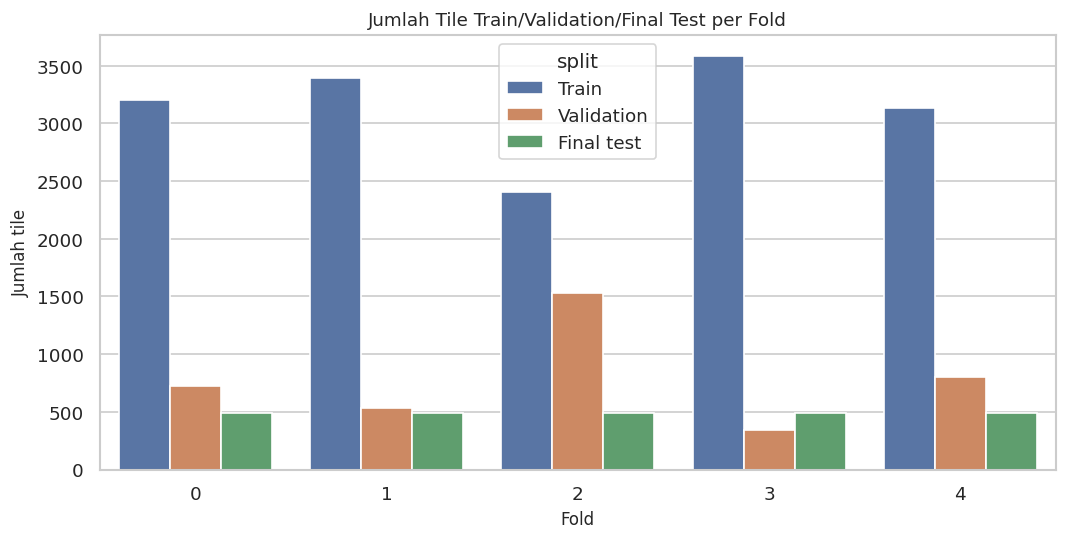

saved figure: outputs/bab4/figures/4_3_spatial_split_diagram.png


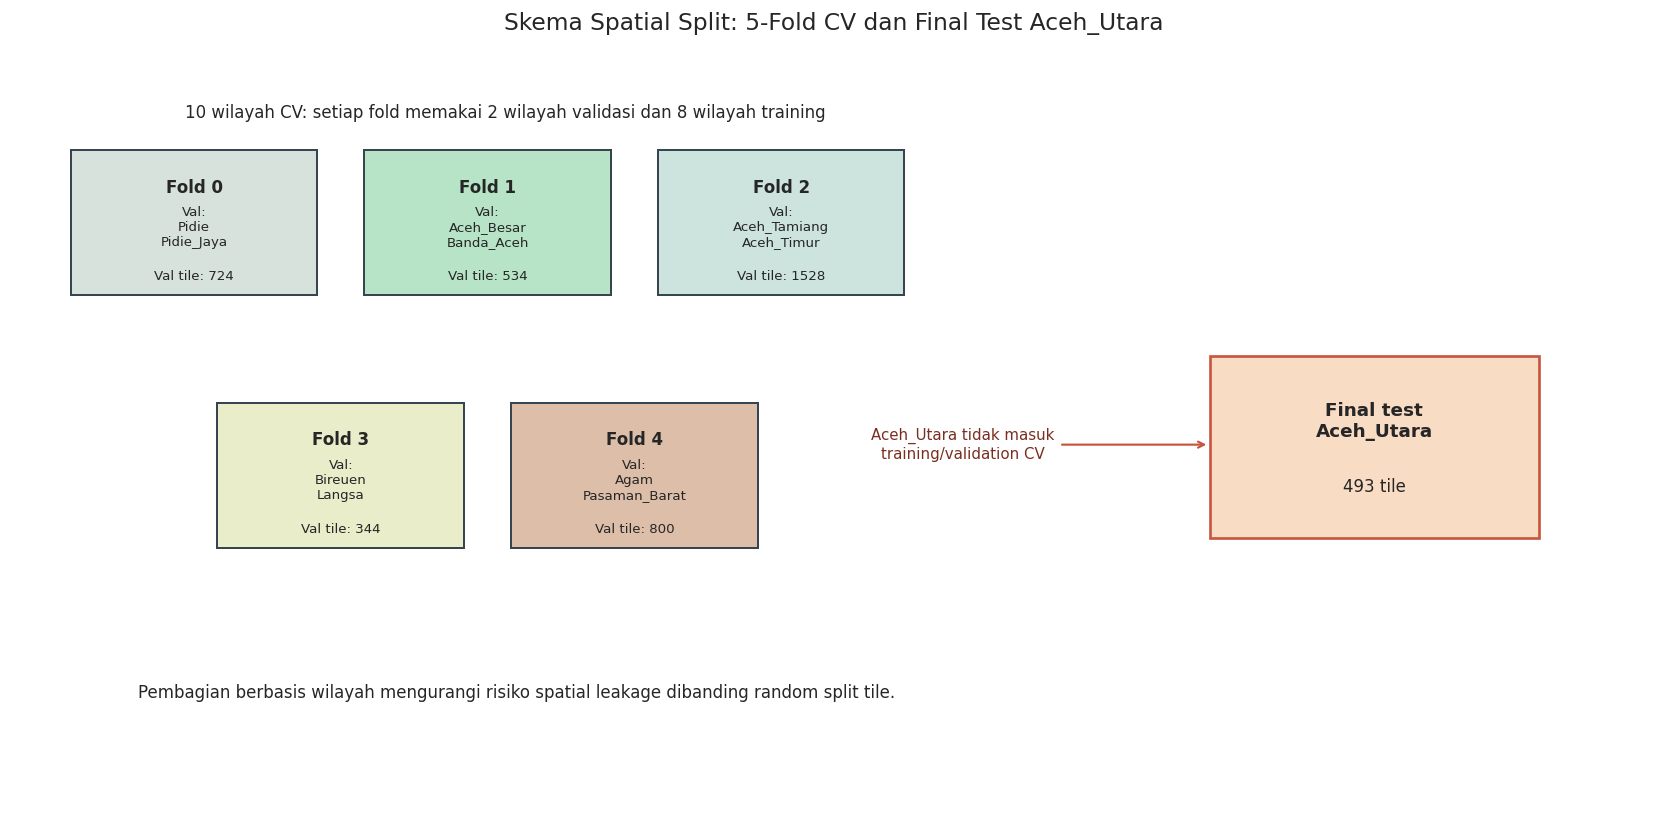

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/figures/4_3_spatial_split_diagram.png')

In [5]:
if "fold_tile_counts" in globals() and not fold_tile_counts.empty:
    plot_df = fold_tile_counts.melt(
        id_vars=["fold"],
        value_vars=["train_tile_count", "validation_tile_count", "final_test_tile_count"],
        var_name="split",
        value_name="tile_count",
    )
    plot_df["split"] = plot_df["split"].map({
        "train_tile_count": "Train",
        "validation_tile_count": "Validation",
        "final_test_tile_count": "Final test",
    })
    fig, ax = plt.subplots(figsize=(9, 4.8))
    sns.barplot(data=plot_df, x="fold", y="tile_count", hue="split", ax=ax)
    ax.set_title("Jumlah Tile Train/Validation/Final Test per Fold")
    ax.set_xlabel("Fold")
    ax.set_ylabel("Jumlah tile")
    save_fig(fig, "4_3_fold_tile_counts.png")

# Diagram skema spatial split yang eksplisit: 10 wilayah CV dan Aceh_Utara final test.
fig, ax = plt.subplots(figsize=(14, 7.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis("off")
ax.set_title("Skema Spatial Split: 5-Fold CV dan Final Test Aceh_Utara", fontsize=14, pad=16)

ax.text(4.2, 7.35, "10 wilayah CV: setiap fold memakai 2 wilayah validasi dan 8 wilayah training", ha="center", fontsize=10)

# CV fold boxes
colors = ["#D8E2DC", "#B7E4C7", "#CCE3DE", "#E9EDC9", "#DDBEA9"]
positions = [(0.5, 5.45), (3.0, 5.45), (5.5, 5.45), (1.75, 2.75), (4.25, 2.75)]
for (fold, val_regions), (x, y), color in zip(fold_defs, positions, colors):
    val_text = "\n".join(val_regions)
    box = plt.Rectangle((x, y), 2.1, 1.55, facecolor=color, edgecolor="#36454F", linewidth=1.2)
    ax.add_patch(box)
    ax.text(x + 1.05, y + 1.15, f"Fold {fold}", ha="center", va="center", fontsize=10, weight="bold")
    ax.text(x + 1.05, y + 0.72, f"Val:\n{val_text}", ha="center", va="center", fontsize=8)
    ax.text(x + 1.05, y + 0.20, f"Val tile: {sum_regions(val_regions)}", ha="center", va="center", fontsize=8)

# Final test box
final_x, final_y = 10.2, 2.85
final_box = plt.Rectangle((final_x, final_y), 2.8, 1.95, facecolor="#F9DCC4", edgecolor="#C8553D", linewidth=1.6)
ax.add_patch(final_box)
ax.text(final_x + 1.4, final_y + 1.25, "Final test\nAceh_Utara", ha="center", va="center", fontsize=11, weight="bold")
ax.text(final_x + 1.4, final_y + 0.55, f"{sum_regions([TEST_REGION])} tile", ha="center", va="center", fontsize=10)

ax.annotate("Aceh_Utara tidak masuk\ntraining/validation CV", xy=(final_x, final_y + 1.0), xytext=(8.1, final_y + 1.0),
            arrowprops=dict(arrowstyle="->", lw=1.3, color="#C8553D"), ha="center", va="center", fontsize=9, color="#7A2E1F")
ax.text(4.3, 1.15, "Pembagian berbasis wilayah mengurangi risiko spatial leakage dibanding random split tile.", ha="center", fontsize=10)
save_fig(fig, "4_3_spatial_split_diagram.png")


## 4.3 Narasi Interpretasi

Menyimpan paragraf siap pakai tentang final test Aceh_Utara, spatial leakage, dan alasan split berbasis wilayah.


In [6]:
test_tiles = sum_regions([TEST_REGION]) if "sum_regions" in globals() else 0
cv_tiles = sum_regions(CV_REGIONS) if "sum_regions" in globals() else 0
interpretation_text = f"""# Interpretasi Pembagian Dataset Spasial 4.3

Aceh_Utara dikunci sebagai wilayah uji final dengan {test_tiles} tile dan tidak dimasukkan ke training maupun validation pada 5-fold spatial cross-validation. Sepuluh wilayah lain digunakan sebagai wilayah cross-validation, dengan dua wilayah menjadi validation pada setiap fold dan delapan wilayah lainnya menjadi training.

Pembagian berbasis wilayah dipakai untuk mengurangi risiko spatial leakage. Pada citra satelit, tile yang berdekatan dapat memiliki tekstur, respons spektral, kondisi topografi, dan pola label yang sangat mirip. Jika tile dari wilayah yang sama dibagi secara acak ke train dan test, evaluasi dapat menjadi terlalu optimistis karena model diuji pada pola spasial yang sudah mirip dengan data latih.

Ringkasan jumlah tile per fold menunjukkan bahwa setiap fold tetap memakai himpunan wilayah validasi yang berbeda, sedangkan final test Aceh_Utara tetap konstan. Dengan demikian, tuning dan analisis stabilitas dilakukan pada 10 wilayah CV, sementara evaluasi akhir tetap dilakukan pada wilayah yang tidak pernah dilihat model selama pemilihan konfigurasi.
"""
path = NARRATIVE_DIR / "4_3_spatial_split_interpretation.md"
path.write_text(interpretation_text, encoding="utf-8")
print(f"saved narrative: {path.relative_to(ROOT)}")
print(interpretation_text)
path


saved narrative: outputs/bab4/narratives/4_3_spatial_split_interpretation.md
# Interpretasi Pembagian Dataset Spasial 4.3

Aceh_Utara dikunci sebagai wilayah uji final dengan 493 tile dan tidak dimasukkan ke training maupun validation pada 5-fold spatial cross-validation. Sepuluh wilayah lain digunakan sebagai wilayah cross-validation, dengan dua wilayah menjadi validation pada setiap fold dan delapan wilayah lainnya menjadi training.

Pembagian berbasis wilayah dipakai untuk mengurangi risiko spatial leakage. Pada citra satelit, tile yang berdekatan dapat memiliki tekstur, respons spektral, kondisi topografi, dan pola label yang sangat mirip. Jika tile dari wilayah yang sama dibagi secara acak ke train dan test, evaluasi dapat menjadi terlalu optimistis karena model diuji pada pola spasial yang sudah mirip dengan data latih.

Ringkasan jumlah tile per fold menunjukkan bahwa setiap fold tetap memakai himpunan wilayah validasi yang berbeda, sedangkan final test Aceh_Utara tetap konstan.

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/narratives/4_3_spatial_split_interpretation.md')

## Checklist 4.3

Memverifikasi artefak 4.3 yang diminta TODO.


In [7]:
expected = [
    ("wajib", "Tabel 5-fold spatial cross-validation", TABLE_DIR / "4_3_five_fold_spatial_cv.csv"),
    ("wajib", "Tabel jumlah tile train/validation/final test per fold", TABLE_DIR / "4_3_fold_tile_counts.csv"),
    ("wajib", "Tabel ringkasan split spasial per fold dan role", TABLE_DIR / "4_3_spatial_split_summary.csv"),
    ("disarankan", "Diagram skema spatial split", FIG_DIR / "4_3_spatial_split_diagram.png"),
    ("disarankan", "Grafik jumlah tile per fold", FIG_DIR / "4_3_fold_tile_counts.png"),
    ("narasi_wajib", "Alasan menghindari random split tile dan spatial leakage", NARRATIVE_DIR / "4_3_spatial_split_interpretation.md"),
    ("disarankan", "Tabel peran wilayah", TABLE_DIR / "4_3_region_role_summary.csv"),
]
checklist_4_3 = pd.DataFrame([
    {"priority": p, "todo_item": item, "artifact": str(path.relative_to(ROOT)), "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else 0}
    for p, item, path in expected
])
save_table(checklist_4_3, "4_3_todo_coverage_checklist.csv")
missing = checklist_4_3[~checklist_4_3["exists"]]
if missing.empty:
    print("All 4.3 TODO artifacts created.")
else:
    print("Missing 4.3 artifacts:")
    display(missing)


saved table: outputs/bab4/tables/4_3_todo_coverage_checklist.csv (7 rows)


,priority,todo_item,artifact,exists,size_bytes
0,wajib,Tabel 5-fold spatial cross-validation,outputs/bab4/tables/4_3_five_fold_spatial_cv.csv,True,1264
1,wajib,Tabel jumlah tile train/validation/final test ...,outputs/bab4/tables/4_3_fold_tile_counts.csv,True,1061
2,wajib,Tabel ringkasan split spasial per fold dan role,outputs/bab4/tables/4_3_spatial_split_summary.csv,True,1163
3,disarankan,Diagram skema spatial split,outputs/bab4/figures/4_3_spatial_split_diagram...,True,218608
4,disarankan,Grafik jumlah tile per fold,outputs/bab4/figures/4_3_fold_tile_counts.png,True,79703
5,narasi_wajib,Alasan menghindari random split tile dan spati...,outputs/bab4/narratives/4_3_spatial_split_inte...,True,1118
6,disarankan,Tabel peran wilayah,outputs/bab4/tables/4_3_region_role_summary.csv,True,507


All 4.3 TODO artifacts created.
